In [1]:
import os
import glob
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.preprocessing import image
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import Callback, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow import keras

from tensorflow.keras.applications import EfficientNetV2L
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_input_efficientnet

Conexión con Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Descomprensión del dataset

In [ ]:
ruta_zip = '/content/drive/MyDrive/archive.zip'
referencia_zip = zipfile.ZipFile(ruta_zip, 'r')
referencia_zip.extractall('/content')
referencia_zip.close()

Conexión con kaggle

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("somesh24/multiclass-images-for-weather-classification")

print("Path to dataset files:", path)

100%|██████████| 91.3M/91.3M [00:01<00:00, 93.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/somesh24/multiclass-images-for-weather-classification/versions/1


Creación del dataFrame

In [3]:
# Carpeta donde quedaron las imágenes
ruta = os.path.join(path, "dataset2")

# Obtener todas las imágenes
rutas_imagenes = list(glob.glob(os.path.join(ruta, "*.jpg")))

# Obtener la etiqueta a partir del nombre del archivo
etiquetas = [
    os.path.basename(img).split('.')[0].rstrip('0123456789')
    for img in rutas_imagenes
]

# Crear el DataFrame
rutas_imagenes = pd.Series(rutas_imagenes, name='Rutas').astype(str)
etiquetas = pd.Series(etiquetas, name='Etiquetas')

datos = pd.concat([rutas_imagenes, etiquetas], axis=1)

# Mezclar aleatoriamente
datos = datos.sample(frac=1, random_state=0).reset_index(drop=True)

datos.head()

,Rutas,Etiquetas
0,/root/.cache/kagglehub/datasets/somesh24/multi...,sunrise
1,/root/.cache/kagglehub/datasets/somesh24/multi...,rain
2,/root/.cache/kagglehub/datasets/somesh24/multi...,cloudy
3,/root/.cache/kagglehub/datasets/somesh24/multi...,rain
4,/root/.cache/kagglehub/datasets/somesh24/multi...,shine


Partición de los datos

In [4]:
dataframe_entrenamiento, dataframe_prueba = train_test_split(datos, test_size=0.2)

input_width = 100
input_height = 100

funcion_preprocesamiento = preprocess_input_efficientnet
datagen_entrenamiento = ImageDataGenerator(preprocessing_function=funcion_preprocesamiento, validation_split=0.2)
datagen_prueba = ImageDataGenerator(preprocessing_function=funcion_preprocesamiento)

gen_entrenamiento = datagen_entrenamiento.flow_from_dataframe(
    dataframe=dataframe_entrenamiento,
    x_col='Rutas',
    y_col='Etiquetas',
    target_size=(input_width, input_height),
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=0,
    subset='training',
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest")

gen_validacion = datagen_entrenamiento.flow_from_dataframe(
    dataframe=dataframe_entrenamiento,
    x_col='Rutas',
    y_col='Etiquetas',
    target_size=(input_width,input_height),
    class_mode='categorical',
    batch_size=32,
    shuffle=False,
    seed=0,
    subset='validation',
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest")

gen_prueba = datagen_prueba.flow_from_dataframe(
    dataframe=dataframe_prueba,
    x_col='Rutas',
    y_col='Etiquetas',
    target_size=(input_width,input_height),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    verbose=0,
    shuffle=False)

Found 718 validated image filenames belonging to 4 classes.
Found 179 validated image filenames belonging to 4 classes.
Found 225 validated image filenames belonging to 4 classes.


Entrenar premodelo

In [5]:
numero_epocas = 200

pre_modelo = EfficientNetV2L(
    input_shape=(input_width,input_height, 3),
    include_top=False,
    weights='imagenet',
    pooling='max'
    )

pre_modelo.trainable = False
entradas = pre_modelo.input
x = Dense(100, activation='relu')(pre_modelo.output)
x = Dense(100, activation='relu')(x)
salidas = Dense(4, activation='softmax')(x)

modelo = Model(inputs=entradas, outputs=salidas)
modelo.compile(loss = 'categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

callbacks = [EarlyStopping(monitor='val_loss',
                          min_delta=0,
                          patience=2,
                          mode='auto')]
historia = modelo.fit(
    gen_entrenamiento,
    validation_data=gen_validacion,
    epochs=numero_epocas,
    callbacks=callbacks,
    verbose=1
)

resultados = modelo.evaluate(gen_prueba, verbose=0)

print("    Perdida prueba: {:.5f}".format(resultados[0]))
print("Precision prueba: {:.2f}%".format(resultados[1] * 100))

473176280/473176280 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 206s 5s/step - accuracy: 0.6713 - loss: 0.8875 - val_accuracy: 0.7374 - val_loss: 0.7244
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - accuracy: 0.8774 - loss: 0.3585 - val_accuracy: 0.8659 - val_loss: 0.3737
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 275ms/step - accuracy: 0.9095 - loss: 0.2466 - val_accuracy: 0.8492 - val_loss: 0.4682
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 186ms/step - accuracy: 0.9206 - loss: 0.2205 - val_accuracy: 0.8827 - val_loss: 0.3515
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - accuracy: 0.9499 - loss: 0.1533 - val_accuracy: 0.8827 - val_loss: 0.3538
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - accuracy: 0.9513 - loss: 0.1318 - val_accuracy: 0.8324 - val_loss: 0.5273
    Perdida prueba: 0.30220
Precision prueba: 91.11%


In [6]:
# Guardar el Modelo
modelo.save('/content/drive/MyDrive/modelo_EfficientNetV2L.h5')

# Recrea exactamente el mismo modelo solo desde el archivo
modelo_cargado = keras.models.load_model('/content/drive/MyDrive/modelo_EfficientNetV2L.h5')

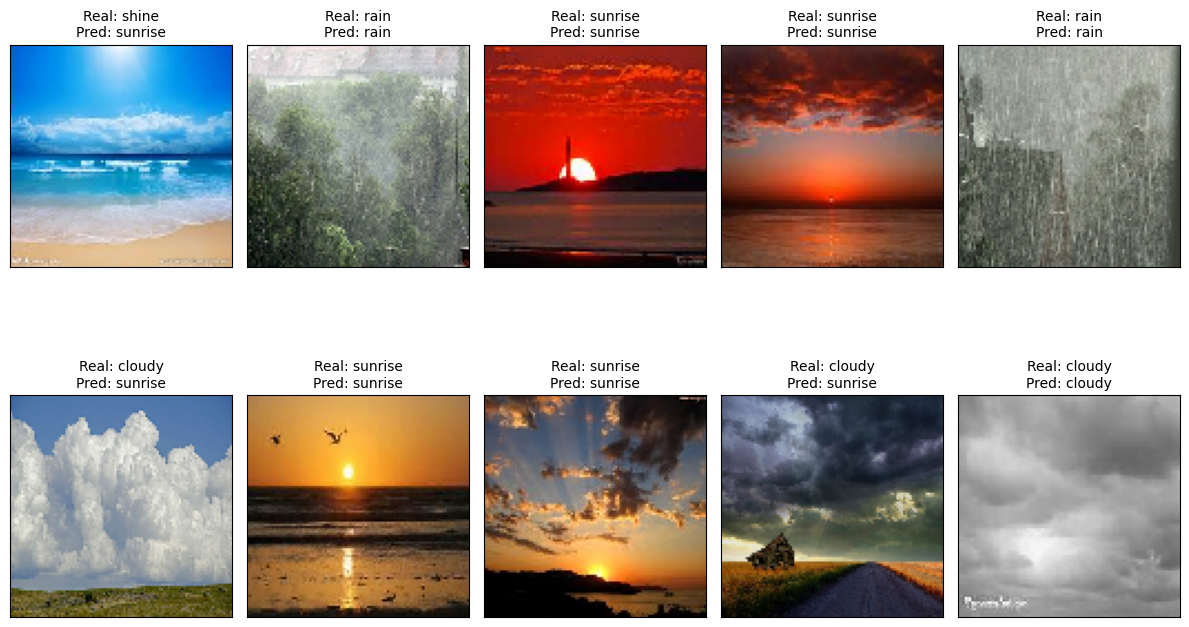

In [8]:
# Diccionario índice -> etiqueta
etiquetas_tests = {v: k for k, v in gen_entrenamiento.class_indices.items()}

# Rutas e etiquetas reales del conjunto de prueba
rutas_imagenes_tests = dataframe_prueba['Rutas'].tolist()
etiquetas_reales = dataframe_prueba['Etiquetas'].tolist()

fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(12,8),
    subplot_kw={'xticks':[], 'yticks':[]}
)

for i, ax in enumerate(axes.flat):

    # Leer imagen
    imagen = image.load_img(
        rutas_imagenes_tests[i],
        target_size=(input_width, input_height)
    )

    ax.imshow(imagen)

    # Preprocesamiento
    x = image.img_to_array(imagen)
    x = np.expand_dims(x, axis=0)
    x = funcion_preprocesamiento(x)

    # Predicción
    pred = modelo.predict(x, verbose=0)
    clase_pred = etiquetas_tests[np.argmax(pred)]

    ax.set_title(
        f"Real: {etiquetas_reales[i]}\nPred: {clase_pred}",
        fontsize=10
    )

plt.tight_layout()
plt.show()